## Exercise Solution — EU AI Act Compliance Plan for an HR Recruitment Screening Tool
## EU AI Act Risk Tier Classifier

In this lab, you will build a Python classifier to determine the risk tier of AI systems under the EU AI Act. The EU AI Act uses a risk-based approach with five tiers (Unacceptable, High-Risk, GPAI [Articles 51–55], Limited, Minimal):

- **Unacceptable Risk**: Prohibited uses (e.g., social scoring systems)
- **High-Risk**: Significant potential impact on fundamental rights
- **GPAI (Articles 51–55)**: General-purpose foundation models. Transparency, copyright disclosure, technical documentation; systemic-risk GPAI adds evaluation + Article 55 obligations. *(Reg. (EU) 2024/1689)*
- **Limited Risk**: Specific transparency requirements
- **Minimal Risk**: Standard transparency requirements

This notebook walks through the classification rules and tests them against example AI systems.

In [1]:
import pandas as pd
from datetime import datetime

print("EU AI Act Compliance Classifier")
print("================================")
print(f"Execution Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

EU AI Act Compliance Classifier
Execution Date: 2026-05-08 14:40:58


## Risk Tier Definitions

The EU AI Act classifies AI systems into five risk categories based on their potential impact and use cases.

In [2]:
# Define EU AI Act risk tiers and their characteristics (5-tier structure; GPAI per Regulation (EU) 2024/1689)
RISK_TIERS = {
    "Unacceptable": {
        "description": "Prohibited uses that create unacceptable risk to fundamental rights",
        "examples": ["Social scoring systems", "Biometric mass surveillance"],
        "articles": ["Article 5"]
    },
    "High-Risk": {
        "description": "Significant potential impact on fundamental rights or safety",
        "examples": ["Recruitment screening", "Credit decisions", "Biometric identification"],
        "articles": ["Article 6", "Article 9 (risk management)", "Article 10 (data governance)",
                     "Article 11 (technical documentation)", "Article 73 (serious-incident reporting — 2 Dec 2027)"]
    },
    "GPAI": {
        "description": "General-Purpose AI models — foundation models, including those with systemic risk. Introduced by Regulation (EU) 2024/1689; without this tier, GPT-class systems are silently classified as Limited, which is incorrect under the current Act.",
        "examples": ["Foundation-model APIs in customer-facing assistants", "RAG systems on top of GPT-class models", "Open-weight foundation models served via API"],
        "articles": ["Article 51 (classification)", "Article 52 (procedure)", "Article 53 (provider obligations)",
                     "Article 54 (authorised representatives)", "Article 55 (systemic-risk GPAI obligations)"]
    },
    "Limited": {
        "description": "Systems with specific transparency requirements",
        "examples": ["Chatbots (non-GPAI)", "Content recommenders", "Emotion recognition"],
        "articles": ["Article 50"]
    },
    "Minimal": {
        "description": "Standard transparency requirements",
        "examples": ["Spam filters", "Video game NPCs", "Internal supply-chain ML"],
        "articles": ["General disclosure"]
    }
}

# Display risk tier definitions
for tier, info in RISK_TIERS.items():
    print(f"\n{tier} Risk:")
    print(f"  Description: {info['description']}")
    print(f"  Applicable Articles: {', '.join(info['articles'])}")



Unacceptable Risk:
  Description: Prohibited uses that create unacceptable risk to fundamental rights
  Applicable Articles: Article 5

High-Risk Risk:
  Description: Significant potential impact on fundamental rights or safety
  Applicable Articles: Article 6, Article 9 (risk management), Article 10 (data governance), Article 11 (technical documentation), Article 73 (serious-incident reporting — 2 Dec 2027)

GPAI Risk:
  Description: General-Purpose AI models — foundation models, including those with systemic risk. Introduced by Regulation (EU) 2024/1689; without this tier, GPT-class systems are silently classified as Limited, which is incorrect under the current Act.
  Applicable Articles: Article 51 (classification), Article 52 (procedure), Article 53 (provider obligations), Article 54 (authorised representatives), Article 55 (systemic-risk GPAI obligations)

Limited Risk:
  Description: Systems with specific transparency requirements
  Applicable Articles: Article 50

Minimal Risk

## EU AI Act Risk Classifier

Below is the rule-based classifier that determines risk tier based on system characteristics.

In [3]:
def classify_ai_system(characteristics):
    '''
    Classify an AI system into a risk tier based on its characteristics.
    Builds dynamic reasoning chains explaining which specific criteria triggered
    the classification.

    Parameters:
    -----------
    characteristics : dict
        A dictionary containing system characteristics including sector,
        biometric use, fundamental rights impact, safety criticality, etc.

    Returns:
    --------
    dict with keys:
        - risk_tier: str - Unacceptable, High-Risk, GPAI, Limited, or Minimal
        - applicable_articles: list - Relevant EU AI Act articles
        - required_actions: list - Compliance actions needed
        - reasoning: str - Dynamic explanation of which criteria triggered classification
    '''

    # Rule 1: Check for UNACCEPTABLE risk — collect specific reasons
    unacceptable_reasons = []
    if characteristics.get('used_for_social_scoring', False):
        unacceptable_reasons.append("assigns social scores to individuals (Article 5(1)(c))")
    if characteristics.get('used_for_predictive_policing', False):
        unacceptable_reasons.append("uses individual predictive policing (Article 5(1)(d))")
    if characteristics.get('generates_deepfakes', False) and characteristics.get('affects_fundamental_rights', False):
        unacceptable_reasons.append("generates deepfakes that affect fundamental rights (Article 5)")

    if unacceptable_reasons:
        return {
            'risk_tier': 'Unacceptable',
            'applicable_articles': ['Article 5'],
            'required_actions': [
                'System is PROHIBITED under EU AI Act',
                'Do not deploy or use this system',
                'Consult with legal and compliance teams immediately'
            ],
            'reasoning': f"System is prohibited because it {'; '.join(unacceptable_reasons)}"
        }

    # Rule 2: Check for HIGH-RISK systems — collect specific triggered criteria
    high_risk_reasons = []
    sector = characteristics.get('sector', '')
    if sector in ['healthcare', 'finance', 'law_enforcement', 'hr']:
        high_risk_reasons.append(f"operates in high-risk sector ({sector})")
    if characteristics.get('uses_biometric_identification', False):
        high_risk_reasons.append("uses biometric identification (Annex III)")
    if characteristics.get('is_safety_component', False):
        high_risk_reasons.append("is a safety component (Annex I)")
    if characteristics.get('affects_fundamental_rights', False):
        high_risk_reasons.append("affects fundamental rights")
    if characteristics.get('determines_access_to_services', False):
        high_risk_reasons.append("determines access to essential services")

    if len(high_risk_reasons) >= 2:
        return {
            'risk_tier': 'High-Risk',
            'applicable_articles': [
                'Article 6 (High-Risk classification)',
                'Article 9 (Risk management system)',
                'Article 10 (Data governance)',
                'Article 11 (Technical documentation)',
                'Article 13 (Transparency)',
                'Article 14 (Human oversight)',
                'Article 15 (Accuracy and robustness)',
                'Article 43 (Conformity assessment)'
            ],
            'required_actions': [
                'Conduct comprehensive impact assessment',
                'Implement human-in-the-loop decision review',
                'Maintain detailed technical documentation',
                'Establish data governance and quality standards',
                'Perform bias testing and fairness evaluation',
                'Maintain audit logs of all decisions',
                'Provide transparency to affected individuals',
                'Undergo third-party conformity assessment',
                'Register with EU AI database'
            ],
            'reasoning': f"System classified as High-Risk because it {'; '.join(high_risk_reasons)}"
        }

    # Rule 3: GPAI tier — check for foundation-model integration BEFORE Limited.
    # Without this, GPT-class systems that interact with humans get silently classified as Limited,
    # which is incorrect under the current EU AI Act. The is_general_purpose_foundation_model signal
    # routes them to GPAI (Articles 51–55) instead.
    if characteristics.get('is_general_purpose_foundation_model', False):
        gpai_articles = [
            'Article 51 (GPAI classification)',
            'Article 52 (Procedure for systemic risk classification)',
            'Article 53 (Provider obligations — transparency to downstream deployers)',
            'Article 54 (Authorised representatives)',
        ]
        gpai_actions = [
            'Transparency to downstream deployers (Art. 53)',
            'Copyright disclosure of training-data sources',
            'Technical documentation per Annex XI',
        ]
        gpai_reasoning_parts = ['system is a general-purpose foundation model']
        if characteristics.get('has_systemic_risk', False):
            gpai_articles.append('Article 55 (Systemic-risk GPAI obligations)')
            gpai_actions.extend([
                'Model evaluation under Art. 55',
                'Adversarial testing + serious-incident reporting',
            ])
            gpai_reasoning_parts.append('classified as systemic-risk under Art. 51')
        return {
            'risk_tier': 'GPAI',
            'applicable_articles': gpai_articles,
            'required_actions': gpai_actions,
            'reasoning': f"Classified as GPAI (Articles 51\u201355) because {'; '.join(gpai_reasoning_parts)}",
        }

    # Rule 3: Check for LIMITED risk — collect transparency triggers
    limited_reasons = []
    if characteristics.get('interacts_with_humans', False):
        limited_reasons.append("interacts directly with humans requiring disclosure")
    if characteristics.get('sector') in ['entertainment', 'content_moderation']:
        limited_reasons.append(f"operates in {characteristics.get('sector')} sector")
    if characteristics.get('generates_deepfakes', False):
        limited_reasons.append("generates synthetic content requiring labeling")

    if limited_reasons:
        return {
            'risk_tier': 'Limited',
            'applicable_articles': [
                'Article 50 (Transparency obligations)'
            ],
            'required_actions': [
                'Disclose AI system use to users',
                'Inform users they are interacting with AI',
                'Maintain records of system outputs (Article 12 record-keeping where applicable)',
                'Provide mechanism to opt-out where feasible',
                'Monitor for misinformation generation'
            ],
            'reasoning': f"System requires transparency obligations because it {'; '.join(limited_reasons)}"
        }

    # Default: MINIMAL risk
    return {
        'risk_tier': 'Minimal',
        'applicable_articles': ['General transparency requirements'],
        'required_actions': [
            'Maintain basic documentation',
            'Ensure no unexpected fundamental rights impact',
            'Monitor for mission creep'
        ],
        'reasoning': 'No high-risk indicators detected; standard transparency requirements apply'
    }

## Test Systems

We'll classify 6 example AI systems across the EU AI Act risk-tier framework (including the GPAI tier under Articles 51–55) to demonstrate the classifier.

In [4]:
# Define test systems — 6 systems covering four of the five risk tiers (GPAI tier per Regulation (EU) 2024/1689)
test_systems = {
    "TalentScope AI": {
        "sector": "hr",
        "description": "AI-powered recruitment screening tool that evaluates candidate CVs and interviews",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": True,
        "is_safety_component": False,
        "interacts_with_humans": False,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": True
    },
    "MediDiagnose": {
        "sector": "healthcare",
        "description": "Medical diagnosis AI for analyzing X-rays and CT scans",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": True,
        "is_safety_component": True,
        "interacts_with_humans": True,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": False
    },
    "AssistGPT Integrator": {
        "sector": "operations",
        "description": "Foundation-model API embedded in a customer-facing operations assistant — GPAI under Articles 51–55",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": False,
        "is_safety_component": False,
        "interacts_with_humans": True,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": False,
        "is_general_purpose_foundation_model": True,
        "has_systemic_risk": False
    },
    "FaceID Secure": {
        "sector": "finance",
        "description": "Facial recognition system for identity verification in banking",
        "uses_biometric_identification": True,
        "affects_fundamental_rights": True,
        "is_safety_component": True,
        "interacts_with_humans": True,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": True
    },
    "SocialScore System": {
        "sector": "government",
        "description": "Social credit scoring system for assigning citizen ratings",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": True,
        "is_safety_component": False,
        "interacts_with_humans": False,
        "generates_deepfakes": False,
        "used_for_social_scoring": True,
        "used_for_predictive_policing": False,
        "determines_access_to_services": False
    },
    "InventoryOptimizer": {
        "sector": "logistics",
        "description": "Internal AI tool that predicts warehouse stock levels for supply chain planning",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": False,
        "is_safety_component": False,
        "interacts_with_humans": False,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": False
    }
}

print(f"Test Systems to Classify: {len(test_systems)}")
for name, chars in test_systems.items():
    print(f"  - {name} ({chars['sector']})")

Test Systems to Classify: 6
  - TalentScope AI (hr)
  - MediDiagnose (healthcare)
  - AssistGPT Integrator (operations)
  - FaceID Secure (finance)
  - SocialScore System (government)
  - InventoryOptimizer (logistics)


## Classify All Systems

In [5]:
# Classify each system
classifications = {}

for system_name, characteristics in test_systems.items():
    classifications[system_name] = classify_ai_system(characteristics)

# Display results for first system (detailed)
print("\n" + "="*70)
print("SAMPLE CLASSIFICATION: TalentScope AI")
print("="*70)
example = classifications["TalentScope AI"]
print(f"\nRisk Tier: {example['risk_tier']}")
print(f"\nApplicable Articles:")
for article in example['applicable_articles']:
    print(f"  - {article}")
print(f"\nRequired Actions:")
for i, action in enumerate(example['required_actions'], 1):
    print(f"  {i}. {action}")
print(f"\nReasoning: {example['reasoning']}")


SAMPLE CLASSIFICATION: TalentScope AI

Risk Tier: High-Risk

Applicable Articles:
  - Article 6 (High-Risk classification)
  - Article 9 (Risk management system)
  - Article 10 (Data governance)
  - Article 11 (Technical documentation)
  - Article 13 (Transparency)
  - Article 14 (Human oversight)
  - Article 15 (Accuracy and robustness)
  - Article 43 (Conformity assessment)

Required Actions:
  1. Conduct comprehensive impact assessment
  2. Implement human-in-the-loop decision review
  3. Maintain detailed technical documentation
  4. Establish data governance and quality standards
  5. Perform bias testing and fairness evaluation
  6. Maintain audit logs of all decisions
  7. Provide transparency to affected individuals
  8. Undergo third-party conformity assessment
  9. Register with EU AI database

Reasoning: System classified as High-Risk because it operates in high-risk sector (hr); affects fundamental rights; determines access to essential services


## Classification Summary

Below is a summary table of all classified systems and their risk tiers.

In [6]:
# Create summary DataFrame
summary_data = []
for system_name, classification in classifications.items():
    summary_data.append({
        'System': system_name,
        'Risk Tier': classification['risk_tier'],
        'Article Count': len(classification['applicable_articles']),
        'Actions Required': len(classification['required_actions']),
        'Key Reasoning': classification['reasoning'][:50] + "..."
    })

summary_df = pd.DataFrame(summary_data)
print("\nCLASSIFICATION SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))

# Count by risk tier
print("\n\nRISK TIER DISTRIBUTION")
print("="*40)
tier_counts = summary_df['Risk Tier'].value_counts()
for tier, count in tier_counts.items():
    print(f"{tier:20s}: {count} system(s)")


CLASSIFICATION SUMMARY
              System    Risk Tier  Article Count  Actions Required                                         Key Reasoning
      TalentScope AI    High-Risk              8                 9 System classified as High-Risk because it operates...
        MediDiagnose    High-Risk              8                 9 System classified as High-Risk because it operates...
AssistGPT Integrator         GPAI              4                 3 Classified as GPAI (Articles 51–55) because system...
       FaceID Secure    High-Risk              8                 9 System classified as High-Risk because it operates...
  SocialScore System Unacceptable              1                 3 System is prohibited because it assigns social sco...
  InventoryOptimizer      Minimal              1                 3 No high-risk indicators detected; standard transpa...


RISK TIER DISTRIBUTION
High-Risk           : 3 system(s)
GPAI                : 1 system(s)
Unacceptable        : 1 system(s)
Mi

## Risk Tier Distribution Visualization

A color-coded bar chart showing how the classified systems distribute across the five EU AI Act risk tiers.

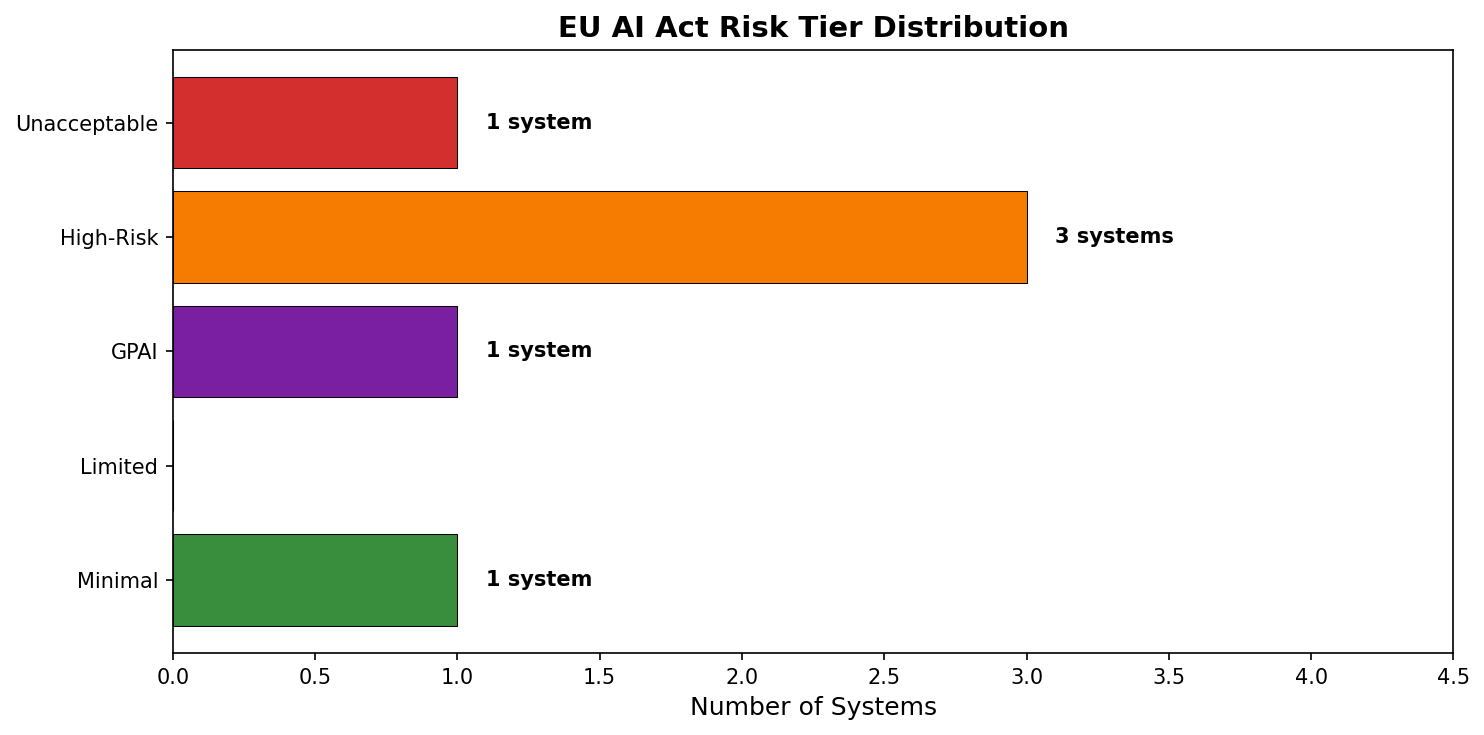

✓ Chart saved to risk_tier_distribution.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

# Count systems per risk tier
tier_order = ['Unacceptable', 'High-Risk', 'GPAI', 'Limited', 'Minimal']
tier_colors = {
    'Unacceptable': '#d32f2f',
    'High-Risk': '#f57c00',
    'GPAI': '#7b1fa2',          # purple — distinct from the High-Risk orange and Limited yellow
    'Limited': '#fbc02d',
    'Minimal': '#388e3c'
}

tier_counts = {}
for tier in tier_order:
    tier_counts[tier] = sum(1 for c in classifications.values() if c['risk_tier'] == tier)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    list(tier_counts.keys()),
    list(tier_counts.values()),
    color=[tier_colors[t] for t in tier_counts.keys()],
    edgecolor='black',
    linewidth=0.5
)

# Add count labels on bars
for bar, count in zip(bars, tier_counts.values()):
    if count > 0:
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{count} system{"s" if count != 1 else ""}',
                va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Systems', fontsize=12)
ax.set_title('EU AI Act Risk Tier Distribution', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(tier_counts.values()) + 1.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('risk_tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved to risk_tier_distribution.png")

## Detailed Classification Results

Below are the complete details for each classified system.

In [8]:
# Display detailed results for each system
for system_name in sorted(classifications.keys()):
    classification = classifications[system_name]
    system_info = test_systems[system_name]

    print(f"\n{'='*70}")
    print(f"SYSTEM: {system_name}")
    print(f"{'='*70}")
    print(f"Description: {system_info['description']}")
    print(f"\nRisk Classification: {classification['risk_tier'].upper()}")
    print(f"\nApplicable Articles:")
    for article in classification['applicable_articles']:
        print(f"  ✓ {article}")
    print(f"\nRequired Compliance Actions:")
    for i, action in enumerate(classification['required_actions'], 1):
        print(f"  {i}. {action}")
    print(f"\nClassification Reasoning:")
    print(f"  {classification['reasoning']}")


SYSTEM: AssistGPT Integrator
Description: Foundation-model API embedded in a customer-facing operations assistant — GPAI under Articles 51–55

Risk Classification: GPAI

Applicable Articles:
  ✓ Article 51 (GPAI classification)
  ✓ Article 52 (Procedure for systemic risk classification)
  ✓ Article 53 (Provider obligations — transparency to downstream deployers)
  ✓ Article 54 (Authorised representatives)

Required Compliance Actions:
  1. Transparency to downstream deployers (Art. 53)
  2. Copyright disclosure of training-data sources
  3. Technical documentation per Annex XI

Classification Reasoning:
  Classified as GPAI (Articles 51–55) because system is a general-purpose foundation model

SYSTEM: FaceID Secure
Description: Facial recognition system for identity verification in banking

Risk Classification: HIGH-RISK

Applicable Articles:
  ✓ Article 6 (High-Risk classification)
  ✓ Article 9 (Risk management system)
  ✓ Article 10 (Data governance)
  ✓ Article 11 (Technical docum

## Export Results

Export the classification results to a CSV file for documentation and compliance tracking.

In [9]:
# Create detailed export DataFrame
export_data = []
for system_name, classification in classifications.items():
    export_data.append({
        'System Name': system_name,
        'Risk Tier': classification['risk_tier'],
        'Description': test_systems[system_name]['description'],
        'Applicable Articles': '; '.join(classification['applicable_articles']),
        'Reasoning': classification['reasoning']
    })

export_df = pd.DataFrame(export_data)

# Save to CSV
output_file = "ai_systems_risk_classification.csv"
export_df.to_csv(output_file, index=False)
print(f"✓ Classification results exported to: {output_file}")
print(f"\nExport Preview:")
print(export_df.to_string(index=False))

✓ Classification results exported to: ai_systems_risk_classification.csv

Export Preview:
         System Name    Risk Tier                                                                                         Description                                                                                                                                                                                                                                                             Applicable Articles                                                                                                                                                                                                                         Reasoning
      TalentScope AI    High-Risk                   AI-powered recruitment screening tool that evaluates candidate CVs and interviews Article 6 (High-Risk classification); Article 9 (Risk management system); Article 10 (Data governance); Article 11 (Technical documentation); Ar

## Lesson Summary

In this lab, you learned:

1. **EU AI Act Risk Framework**: Understanding the five risk tiers (Unacceptable, High-Risk, GPAI [Articles 51–55], Limited, Minimal) — the GPAI tier comes from Regulation (EU) 2024/1689 of the framework
2. **Risk Characteristics**: How to evaluate AI systems based on their sector, use case, and impact
3. **Regulatory Mapping**: Identifying applicable articles and required compliance actions
4. **Implementation**: Building a Python classifier to automate risk assessment

### Key Takeaways:
- **Unacceptable Risk** systems must not be deployed
- **High-Risk** systems require comprehensive compliance frameworks
- **GPAI** (foundation-model integrations) require the Article 51–55 obligations stack — model documentation, copyright policy, and (for systemic-risk models) red-teaming and incident reporting
- **Limited Risk** systems need transparency mechanisms
- **Minimal Risk** systems require basic documentation

### Next Steps:
- Apply this classifier to your organization's AI systems
- Map each system to specific compliance controls
- Develop remediation plans for gaps
- Maintain ongoing compliance monitoring

## Edge Case Analysis

Real-world AI systems often sit at the boundaries between risk tiers. Below we classify two ambiguous systems and discuss why the tier assignment is debatable.

In [10]:
# Edge Case 1: EmotionSense HR
# AI that analyzes employee facial expressions during video meetings
# to generate team morale reports for managers.
edge_case_systems = {
    "EmotionSense HR": {
        "sector": "hr",
        "description": "AI analyzing employee facial expressions during video meetings to assess engagement and productivity",
        "uses_biometric_identification": True,  # facial analysis = biometric
        "affects_fundamental_rights": True,      # workplace surveillance, privacy
        "is_safety_component": False,
        "interacts_with_humans": True,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": False
    },
    "EduTutor AI": {
        "sector": "education",
        "description": "GenAI tutoring chatbot for K-12 students that adapts lesson content based on student performance",
        "uses_biometric_identification": False,
        "affects_fundamental_rights": True,      # educational access for minors
        "is_safety_component": False,
        "interacts_with_humans": True,
        "generates_deepfakes": False,
        "used_for_social_scoring": False,
        "used_for_predictive_policing": False,
        "determines_access_to_services": True    # determines learning paths
    }
}

# Classify edge cases
print("EDGE CASE CLASSIFICATION RESULTS")
print("=" * 70)
for name, chars in edge_case_systems.items():
    result = classify_ai_system(chars)
    print(f"\n{name}")
    print(f"  Description: {chars['description']}")
    print(f"  Classifier Result: {result['risk_tier']}")
    print(f"  Reasoning: {result['reasoning']}")
    print()

EDGE CASE CLASSIFICATION RESULTS

EmotionSense HR
  Description: AI analyzing employee facial expressions during video meetings to assess engagement and productivity
  Classifier Result: High-Risk
  Reasoning: System classified as High-Risk because it operates in high-risk sector (hr); uses biometric identification (Annex III); affects fundamental rights


EduTutor AI
  Description: GenAI tutoring chatbot for K-12 students that adapts lesson content based on student performance
  Classifier Result: High-Risk
  Reasoning: System classified as High-Risk because it affects fundamental rights; determines access to essential services



### Edge Case Discussion

**EmotionSense HR** — Our classifier assigns **High-Risk** based on HR sector + biometric identification + fundamental rights impact. However, a strong argument exists for **Unacceptable**: Article 5(1)(f) of the EU AI Act prohibits "emotion recognition systems in the workplace" except for medical or safety reasons. Employee facial monitoring for productivity directly conflicts with worker dignity protections. A compliance officer should flag this for legal review rather than relying on the classifier alone.

**EduTutor AI** — Our classifier assigns **High-Risk** based on fundamental rights impact + access to services. This is debatable: as a chatbot it might seem **Limited** (transparency only), but it affects children's education — a fundamental right — and determines personalized learning paths that shape educational outcomes. The EU AI Act lists educational AI in Annex III (High-Risk), confirming the classifier's output. However, the GenAI aspect adds complexity: hallucinated educational content could actively mislead minors.

**Key Insight:** Rule-based classifiers handle clear cases well but struggle with nuance at tier boundaries. Real-world EU AI Act compliance requires human judgment alongside automation — particularly for systems that touch biometric data in sensitive contexts or affect vulnerable populations like children.

## Reference Notes

A few specification details for cross-referencing the EU AI Act citations used in this lesson:

- **GPAI tier provenance.** Articles 51–55 (GPAI) were introduced in Regulation (EU) 2024/1689 itself when adopted in June 2024. The substantive GPAI obligations became applicable on 2 August 2025. The broader high-risk regime was then deferred by Regulation (EU) 2026/1744: it becomes generally applicable on 2 December 2027 for stand-alone Annex III systems and 2 August 2028 for high-risk AI embedded in products already covered by EU product-safety law. Those dates concern applicability of the wider regime, not the introduction of GPAI.
- **Article 10 vs Article 15.** The bias-prevention obligation sits in **Article 10(2)(f)–(g)** (data and data governance), not Article 15 (which covers accuracy, robustness, cybersecurity). The Compliance Matrix solution has been updated to reflect this.
- **Article 13 vs Article 50.** Article 13 governs provider-to-deployer transparency for high-risk systems. End-user / affected-person disclosure (chatbots, deepfakes, biometric/emotion-recognition notice) sits in **Article 50**; both can apply in tandem when a high-risk system is also user-facing.
- **Article 73 deadlines are tiered.** 15 days is the general default; **2 days** for widespread-infringement incidents (Art. 3(49)(b)); **10 days** for incidents involving death.
- **Annex I vs Annex III.** Annex III lists eight specific use-case areas; Annex I captures AI that is also a regulated product (or safety component) under product-safety legislation (EU MDR / IVDR, Machinery Regulation, etc.). Camera-based worker-safety systems and clinical decision support typically route through Annex I; pure-software AI for credit / hiring / biometrics routes through Annex III.